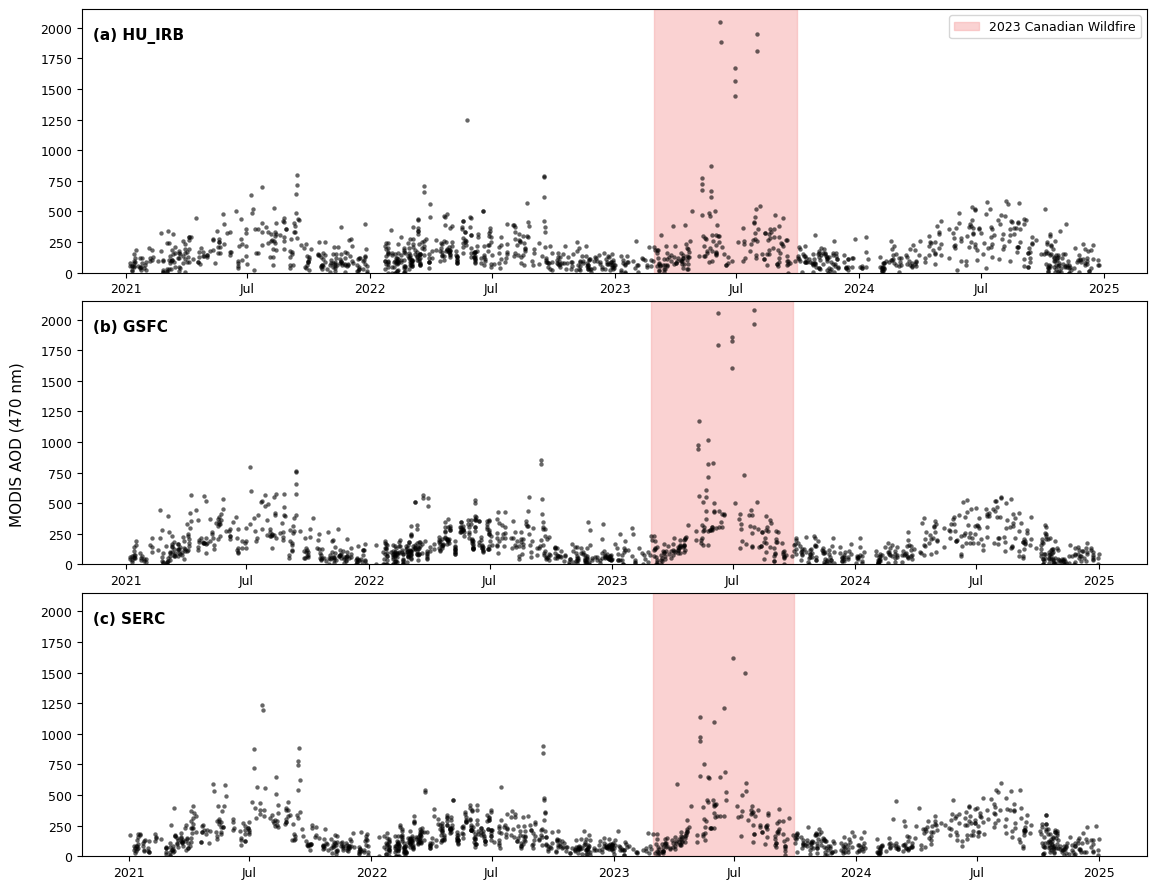

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data
df = pd.read_csv("/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_Extraction.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

stations = stations = ["HU_IRB", "GSFC", "SERC"]
labels   = [f"({chr(97+i)})" for i in range(len(stations))]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(len(stations), 1, figsize=(12, 9), sharey=True)
if len(stations) == 1:
    axes = [axes]

for ax, station, label in zip(axes, stations, labels):
    subset = df[df["station"] == station].dropna(subset=["AOD_470"]).sort_values("datetime")

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(subset["datetime"], subset["AOD_470"],
               s=10, color="black", alpha=0.6, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {station}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

# Shared Y-axis label
fig.text(0.04, 0.5, "MODIS AOD (470 nm)", va="center", rotation="vertical", fontsize=11)

# X-axis formatting — Jan (year label, full tick) + Jul (minor-style tick)
# Major ticks at Jan & Jul; Jul gets smaller tick line to look secondary
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))

def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jul"

axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))

fig.canvas.draw()
for tick in axes[-1].xaxis.get_major_ticks():
    if tick.label1.get_text() == "July":
        tick.tick1line.set_markersize(3)   # shorter tick = minor-style
        tick.tick2line.set_markersize(3)
        tick.label1.set_fontsize(5)
        # tick.label1.set_color("black")

axes[-1].tick_params(axis="x", which="major", labelsize=9)

# Show x-tick labels on ALL subplots (sharex hides them by default)
for ax in axes[:-1]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))
    plt.setp(ax.get_xticklabels(), visible=True)
    fig.canvas.draw()
    for tick in ax.xaxis.get_major_ticks():
        if tick.label1.get_text() == "July":
            tick.tick1line.set_markersize(3)
            tick.tick2line.set_markersize(3)
            tick.label1.set_fontsize(5)
            # tick.label1.set_color("gray")
    ax.tick_params(axis="x", which="major", labelsize=9)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)
plt.savefig("/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_time_series.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
import pandas as pd

# ── 1. Load & preprocess MODIS ──────────────────────────────────────────────
modis_df = pd.read_csv("/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_Extraction.csv")
modis_df["datetime"] = pd.to_datetime(modis_df["datetime"])
modis_df["AOD_470"]  = modis_df["AOD_470"] / 1000   # scale factor: stored as int*1000

# ── 2. Load & preprocess AERONET (Angstrom exponent only) ───────────────────
FILL = -999   # AERONET missing value flag
ae_frames = []

for site in ["HU_IRB", "GSFC", "SERC"]:
    df = pd.read_csv(
        f"/Users/ujjawal/Downloads/Ceilometer Script/data/{site}/{site}_AOD20_combined.csv",
        low_memory=False
    )

    # Parse datetime
    df["datetime"] = pd.to_datetime(
        df["Date(dd:mm:yyyy)"] + " " + df["Time(hh:mm:ss)"],
        format="%d:%m:%Y %H:%M:%S"
    )

    # Keep only what we need
    df = df[["datetime", "440-675_Angstrom_Exponent"]].copy()
    df.rename(columns={"440-675_Angstrom_Exponent": "AE_440_675"}, inplace=True)

    # Drop fill values
    df = df[df["AE_440_675"] != FILL].dropna(subset=["AE_440_675"])

    df["station"] = site
    ae_frames.append(df)

aeronet_df = pd.concat(ae_frames).sort_values("datetime").reset_index(drop=True)

# ── 3. Temporal match: nearest AERONET obs within ±30 min of MODIS overpass ─
modis_df  = modis_df.sort_values("datetime")
aeronet_df = aeronet_df.sort_values("datetime")

merged_df = pd.merge_asof(
    modis_df,
    aeronet_df,
    on="datetime",
    by="station",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=30)
)

# ── 4. Convert AOD 470 → 500 nm using Angstrom Exponent ─────────────────────
merged_df["MODIS_AOD_500"] = merged_df["AOD_470"] * ((500 / 470) ** -merged_df["AE_440_675"])

# ── 5. Report match rate & save ──────────────────────────────────────────────
n_total   = len(merged_df)
n_matched = merged_df["MODIS_AOD_500"].notna().sum()
print(f"Matched: {n_matched}/{n_total} ({100*n_matched/n_total:.1f}%)")
print(merged_df[["station","datetime","AOD_470","AE_440_675","MODIS_AOD_500"]].dropna().head(10))

out_path = "/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_Extraction_500nm.csv"
merged_df[["station","datetime","AOD_470","AE_440_675","MODIS_AOD_500"]].to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_2483/1208804326.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["datetime"] = pd.to_datetime(


Matched: 2184/3699 (59.0%)
   station            datetime  AOD_470  AE_440_675  MODIS_AOD_500
1     GSFC 2021-01-07 16:40:00    0.047    1.512174       0.042802
3     SERC 2021-01-07 16:40:00    0.054    1.488981       0.049247
4     GSFC 2021-01-07 18:20:00    0.058    1.477803       0.052932
6     SERC 2021-01-07 18:20:00    0.081    1.520795       0.073726
9     GSFC 2021-01-09 18:05:00    0.039    1.148668       0.036324
11    SERC 2021-01-09 18:05:00    0.028    1.169702       0.026045
12    SERC 2021-01-10 15:30:00    0.080    1.336817       0.073649
14    GSFC 2021-01-10 15:30:00    0.067    1.273244       0.061924
15    GSFC 2021-01-10 18:50:00    0.021    1.254336       0.019432
17    SERC 2021-01-10 18:50:00    0.042    1.261298       0.038847

Saved → /Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_Extraction_500nm.csv


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_2483/1208804326.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_2483/1208804326.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["datetime"] = pd.to_datetime(


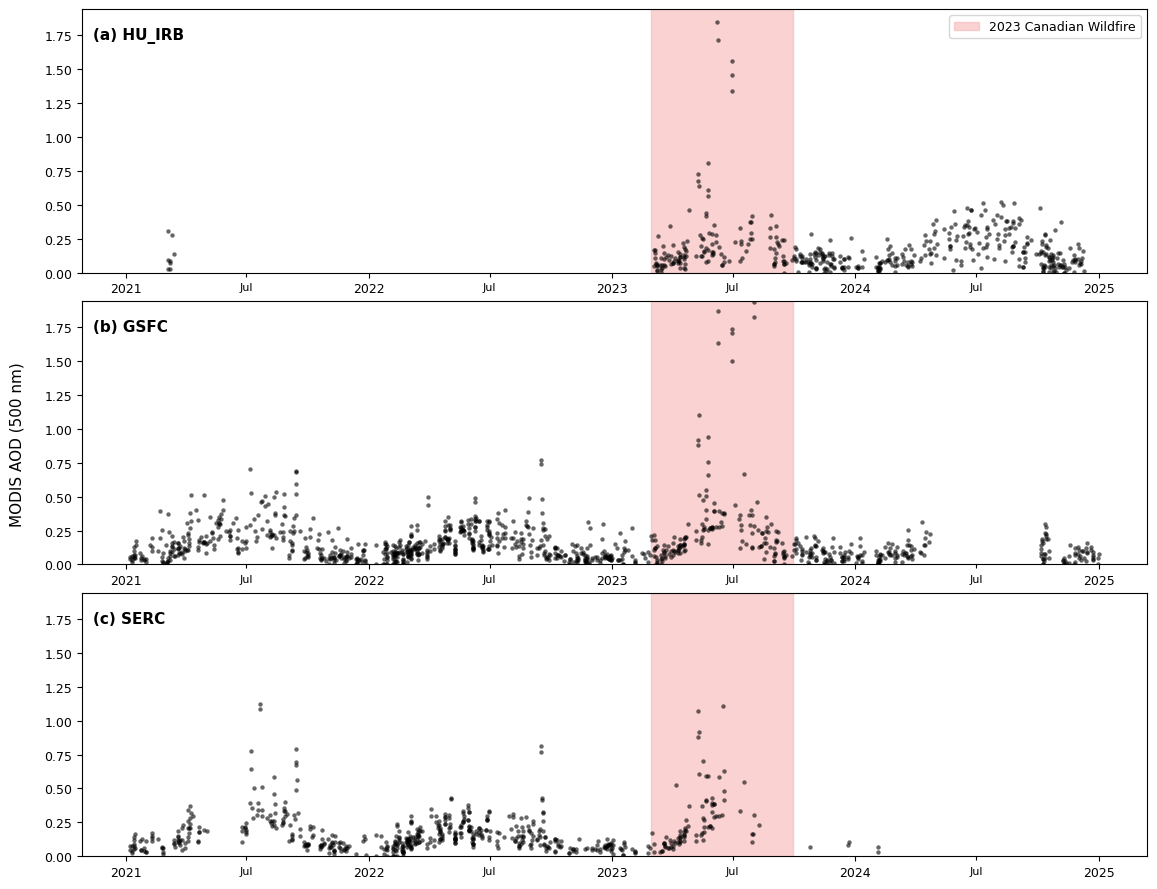

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_Extraction_500nm.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

stations = ["HU_IRB", "GSFC", "SERC"]
labels   = [f"({chr(97+i)})" for i in range(len(stations))]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(len(stations), 1, figsize=(12, 9), sharex=True, sharey=True)

for ax, station, label in zip(axes, stations, labels):
    subset = df[df["station"] == station].dropna(subset=["MODIS_AOD_500"]).sort_values("datetime")

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(subset["datetime"], subset["MODIS_AOD_500"],
               s=10, color="black", alpha=0.6, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {station}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

fig.text(0.04, 0.5, "MODIS AOD (500 nm)", va="center", rotation="vertical", fontsize=11)

def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jul"

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))
    ax.tick_params(axis="x", which="major", labelsize=9, labelbottom=True)
    fig.canvas.draw()
    for tick in ax.xaxis.get_major_ticks():
        if tick.label1.get_text() == "Jul":
            tick.tick1line.set_markersize(3)
            tick.tick2line.set_markersize(3)
            tick.label1.set_fontsize(8)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)
# plt.savefig("/Users/ujjawal/Downloads/Ceilometer Script/data/MODIS_AOD_500_time_series.png", dpi=300, bbox_inches="tight")
plt.show()
